<a href="https://colab.research.google.com/github/shambhavi2177/Decision-Support-System/blob/main/DSS_SIH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install pandas numpy scikit-learn matplotlib seaborn folium geopandas pyproj shapely

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the datasets
dummy_data = pd.read_csv('/content/DSS_FRA_Holder_RealNames_First25.csv')
rules_data = pd.read_csv('/content/eligibility_matrix.csv')

# Display basic info
print("Dummy Data Shape:", dummy_data.shape)
print("Rules Data Shape:", rules_data.shape)

print("\nDummy Data Columns:")
print(dummy_data.columns.tolist())

print("\nRules Data Columns:")
print(rules_data.columns.tolist())

print("\nDummy Data Sample:")
print(dummy_data.head())

print("\nRules Data:")
print(rules_data)

Dummy Data Shape: (25, 24)
Rules Data Shape: (12, 9)

Dummy Data Columns:
['Village_Name', 'District', 'State', 'Rural_Urban', 'ST_PVTG_Household', 'Household_Size', 'BPL', 'Pucca_House', 'Functional_Tap_Connection', 'Road_Connectivity', 'Distance_to_School_km', 'Distance_to_Health_Facility_km', 'Access_to_Electricity', 'Irrigation_Coverage_pct', 'Remote_Forest_Drought_Area', 'Literacy_Rate_pct', 'Adult_Seeking_Manual_Work', 'DAJGUA_Eligible', 'PMAAGY_Eligible', 'PM_JANMAN_Eligible', 'MGNREGA_Eligible', 'PMGSY_Eligible', 'Jal_Jeevan_Eligible', 'EMRS_Eligible']

Rules Data Columns:
['FeatureID', 'Feature', 'DAJGUA', 'PMAAGY', 'PM-JANMAN', 'MGNREGA', 'PMGSY', 'JJM', 'EMRS']

Dummy Data Sample:
  Village_Name  District          State Rural_Urban ST_PVTG_Household  \
0       Rampur  Varanasi  Uttar Pradesh         Yes                No   
1     Nandgaon  Mirzapur  Uttar Pradesh         Yes                No   
2       Rajpur   Jaunpur  Uttar Pradesh         Yes                No   
3   Bha

In [ ]:
def preprocess_fra_data(df):
    """Preprocess the FRA dataset"""
    processed_df = df.copy()

    # Convert Yes/No to binary (1/0)
    binary_columns = ['Rural_Urban', 'ST_PVTG_Household', 'BPL', 'Pucca_House',
                     'Functional_Tap_Connection', 'Road_Connectivity', 'Access_to_Electricity',
                     'Remote_Forest_Drought_Area', 'Adult_Seeking_Manual_Work']

    for col in binary_columns:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].map({'Yes': 1, 'No': 0})

    # Handle missing values in eligibility columns (currently empty)
    scheme_columns = ['DAJGUA_Eligible', 'PMAAGY_Eligible', 'PM_JANMAN_Eligible',
                     'MGNREGA_Eligible', 'PMGSY_Eligible', 'Jal_Jeevan_Eligible', 'EMRS_Eligible']

    for col in scheme_columns:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].fillna(0)  # 0 means not evaluated yet

    return processed_df

# Preprocess the data
processed_data = preprocess_fra_data(dummy_data)
print("Processed Data Info:")
print(processed_data.info())
print("\nProcessed Data Sample:")
print(processed_data.head())

Processed Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Village_Name                    25 non-null     object 
 1   District                        25 non-null     object 
 2   State                           25 non-null     object 
 3   Rural_Urban                     25 non-null     int64  
 4   ST_PVTG_Household               25 non-null     int64  
 5   Household_Size                  25 non-null     int64  
 6   BPL                             25 non-null     int64  
 7   Pucca_House                     25 non-null     int64  
 8   Functional_Tap_Connection       25 non-null     int64  
 9   Road_Connectivity               25 non-null     int64  
 10  Distance_to_School_km           25 non-null     float64
 11  Distance_to_Health_Facility_km  25 non-null     float64
 12  Access_to_Electri

In [ ]:
class FRADecisionSupportSystem:
    def __init__(self, rules_df):
        self.rules_df = rules_df
        self.schemes = ['DAJGUA', 'PMAAGY', 'PM-JANMAN', 'MGNREGA', 'PMGSY', 'JJM', 'EMRS']
        self.feature_mapping = self._create_feature_mapping()

    def _create_feature_mapping(self):
        """Map rule features to dataset columns"""
        mapping = {
            'F1': 'Rural_Urban',
            'F2': 'ST_PVTG_Household',
            'F3': 'Household_Size',  # Will need population proxy
            'F4': 'Functional_Tap_Connection',
            'F5': 'Road_Connectivity',
            'F6': 'Pucca_House',
            'F7': 'Distance_to_School_km',
            'F8': 'Distance_to_Health_Facility_km',
            'F9': 'Adult_Seeking_Manual_Work',
            'F10': 'Remote_Forest_Drought_Area',
            'F11': 'BPL',
            'F12': 'Literacy_Rate_pct'
        }
        return mapping

    def _check_population_threshold(self, household_size, rural_urban, st_pvtg):
        """Check population threshold (F3) - using household size as proxy"""
        # For plains: ≥500, for tribal/hilly: ≥250
        # Using household size as proxy (assuming average 5 per household)
        estimated_population = household_size * 5  # Rough estimate

        if st_pvtg == 1:  # Tribal area
            return estimated_population >= 50  # 50 people ≈ 10 households
        else:  # Plains area
            return estimated_population >= 100  # 100 people ≈ 20 households

    def _check_distance_threshold(self, distance, threshold=5):
        """Check if distance is beyond threshold (for eligibility)"""
        return distance > threshold

    def evaluate_dajgua(self, record):
        """Evaluate DAJGUA eligibility"""
        conditions = []

        # F1: Rural area
        conditions.append(record.get('Rural_Urban', 0) == 1)

        # F2: ST/PVTG household
        conditions.append(record.get('ST_PVTG_Household', 0) == 1)

        # F3: Population threshold
        conditions.append(self._check_population_threshold(
            record.get('Household_Size', 0),
            record.get('Rural_Urban', 0),
            record.get('ST_PVTG_Household', 0)
        ))

        # F4: Functional tap connection (No->Eligible)
        conditions.append(record.get('Functional_Tap_Connection', 0) == 0)

        # F5: Road connectivity (No->Eligible)
        conditions.append(record.get('Road_Connectivity', 0) == 0)

        # F10: Remote/forest/drought area
        conditions.append(record.get('Remote_Forest_Drought_Area', 0) == 1)

        # F11: BPL (priority)
        conditions.append(record.get('BPL', 0) == 1)

        # F12: Literacy < 60%
        conditions.append(record.get('Literacy_Rate_pct', 100) < 60)

        # Return score and eligibility
        score = sum(conditions)
        eligible = score >= 4  # At least 4 conditions must be met

        return {
            'eligible': eligible,
            'score': score,
            'max_score': len(conditions),
            'priority': 'High' if record.get('BPL', 0) == 1 else 'Medium'
        }

    def evaluate_pm_janman(self, record):
        """Evaluate PM-JANMAN eligibility"""
        conditions = []

        # F1: Rural area
        conditions.append(record.get('Rural_Urban', 0) == 1)

        # F2: ST/PVTG household
        conditions.append(record.get('ST_PVTG_Household', 0) == 1)

        # F3: Population threshold
        conditions.append(self._check_population_threshold(
            record.get('Household_Size', 0),
            record.get('Rural_Urban', 0),
            record.get('ST_PVTG_Household', 0)
        ))

        # F4: Functional tap connection (No->Eligible)
        conditions.append(record.get('Functional_Tap_Connection', 0) == 0)

        # F5: Road connectivity (No->Eligible)
        conditions.append(record.get('Road_Connectivity', 0) == 0)

        # F6: Pucca house (No->Eligible)
        conditions.append(record.get('Pucca_House', 0) == 0)

        # F7: School within 5km (No->Eligible)
        conditions.append(self._check_distance_threshold(record.get('Distance_to_School_km', 10)))

        # F8: Health facility within 5km (No->Eligible)
        conditions.append(self._check_distance_threshold(record.get('Distance_to_Health_Facility_km', 10)))

        # F10: Remote/forest/drought area
        conditions.append(record.get('Remote_Forest_Drought_Area', 0) == 1)

        # F11: BPL
        conditions.append(record.get('BPL', 0) == 1)

        # F12: Literacy < 60%
        conditions.append(record.get('Literacy_Rate_pct', 100) < 60)

        score = sum(conditions)
        eligible = score >= 5  # At least 5 conditions

        return {
            'eligible': eligible,
            'score': score,
            'max_score': len(conditions),
            'priority': 'High' if record.get('BPL', 0) == 1 else 'Medium'
        }

    def evaluate_mgnrega(self, record):
        """Evaluate MGNREGA eligibility"""
        conditions = []

        # F9: Adult seeking manual work
        conditions.append(record.get('Adult_Seeking_Manual_Work', 0) == 1)

        # F10: Remote area (priority)
        conditions.append(record.get('Remote_Forest_Drought_Area', 0) == 1)

        # F11: BPL
        conditions.append(record.get('BPL', 0) == 1)

        score = sum(conditions)
        eligible = score >= 1  # At least one condition

        return {
            'eligible': eligible,
            'score': score,
            'max_score': len(conditions),
            'priority': 'High' if record.get('BPL', 0) == 1 else 'Medium'
        }

    def evaluate_jjm(self, record):
        """Evaluate Jal Jeevan Mission eligibility"""
        conditions = []

        # F1: Rural area
        conditions.append(record.get('Rural_Urban', 0) == 1)

        # F2: ST/PVTG (priority)
        conditions.append(record.get('ST_PVTG_Household', 0) == 1)

        # F4: Functional tap connection (No->Eligible)
        conditions.append(record.get('Functional_Tap_Connection', 0) == 0)

        # F10: Remote/forest/drought area
        conditions.append(record.get('Remote_Forest_Drought_Area', 0) == 1)

        # F11: BPL
        conditions.append(record.get('BPL', 0) == 1)

        score = sum(conditions)
        eligible = score >= 2  # At least 2 conditions

        return {
            'eligible': eligible,
            'score': score,
            'max_score': len(conditions),
            'priority': 'High' if record.get('ST_PVTG_Household', 0) == 1 else 'Medium'
        }

    def evaluate_emrs(self, record):
        """Evaluate EMRS eligibility"""
        conditions = []

        # F1: Rural area
        conditions.append(record.get('Rural_Urban', 0) == 1)

        # F2: ST/PVTG household
        conditions.append(record.get('ST_PVTG_Household', 0) == 1)

        # F3: Population threshold
        conditions.append(self._check_population_threshold(
            record.get('Household_Size', 0),
            record.get('Rural_Urban', 0),
            record.get('ST_PVTG_Household', 0)
        ))

        # F7: School within 5km (No->Eligible)
        conditions.append(self._check_distance_threshold(record.get('Distance_to_School_km', 10)))

        # F10: Remote/forest/drought area
        conditions.append(record.get('Remote_Forest_Drought_Area', 0) == 1)

        # F11: BPL
        conditions.append(record.get('BPL', 0) == 1)

        # F12: Literacy < 60%
        conditions.append(record.get('Literacy_Rate_pct', 100) < 60)

        score = sum(conditions)
        eligible = score >= 3  # At least 3 conditions

        return {
            'eligible': eligible,
            'score': score,
            'max_score': len(conditions),
            'priority': 'High' if record.get('ST_PVTG_Household', 0) == 1 else 'Medium'
        }

    def evaluate_all_schemes(self, record):
        """Evaluate all schemes for a given record"""
        evaluations = {}

        evaluations['DAJGUA'] = self.evaluate_dajgua(record)
        evaluations['PM-JANMAN'] = self.evaluate_pm_janman(record)
        evaluations['MGNREGA'] = self.evaluate_mgnrega(record)
        evaluations['JJM'] = self.evaluate_jjm(record)
        evaluations['EMRS'] = self.evaluate_emrs(record)

        # For schemes with simpler rules
        evaluations['PMAAGY'] = evaluations['DAJGUA']  # Similar to DAJGUA
        evaluations['PMGSY'] = {
            'eligible': record.get('Road_Connectivity', 0) == 0,
            'score': 1 if record.get('Road_Connectivity', 0) == 0 else 0,
            'max_score': 1,
            'priority': 'High' if record.get('Remote_Forest_Drought_Area', 0) == 1 else 'Medium'
        }

        return evaluations

# Initialize DSS
dss_engine = FRADecisionSupportSystem(rules_data)

In [ ]:
def apply_dss_to_dataset(dss, dataset):
    """Apply DSS to entire dataset"""
    results = []

    for idx, record in dataset.iterrows():
        village_name = record['Village_Name']
        district = record['District']

        # Evaluate schemes for this record
        scheme_evaluations = dss.evaluate_all_schemes(record)

        # Create result entry
        result = {
            'Village_Name': village_name,
            'District': district,
            'State': record['State']
        }

        # Add scheme evaluations
        for scheme, evaluation in scheme_evaluations.items():
            result[f'{scheme}_Eligible'] = 1 if evaluation['eligible'] else 0
            result[f'{scheme}_Score'] = evaluation['score']
            result[f'{scheme}_Priority'] = evaluation['priority']

        results.append(result)

    return pd.DataFrame(results)

# Apply DSS to processed data
dss_results = apply_dss_to_dataset(dss_engine, processed_data)

print("DSS Results:")
print(dss_results.head())

# Display eligibility summary
schemes = ['DAJGUA', 'PMAAGY', 'PM-JANMAN', 'MGNREGA', 'PMGSY', 'JJM', 'EMRS']
print("\nEligibility Summary:")
for scheme in schemes:
    eligible_count = dss_results[f'{scheme}_Eligible'].sum()
    total_count = len(dss_results)
    print(f"{scheme}: {eligible_count}/{total_count} villages eligible ({eligible_count/total_count*100:.1f}%)")

DSS Results:
  Village_Name  District          State  DAJGUA_Eligible  DAJGUA_Score  \
0       Rampur  Varanasi  Uttar Pradesh                1             4   
1     Nandgaon  Mirzapur  Uttar Pradesh                0             2   
2       Rajpur   Jaunpur  Uttar Pradesh                1             4   
3   Bhawanipur     Patna          Bihar                0             2   
4     Gopalpur   Nalanda          Bihar                1             4   

  DAJGUA_Priority  PM-JANMAN_Eligible  PM-JANMAN_Score PM-JANMAN_Priority  \
0            High                   1                6               High   
1          Medium                   0                4             Medium   
2          Medium                   1                6             Medium   
3          Medium                   0                4             Medium   
4            High                   1                5               High   

   MGNREGA_Eligible  ...  JJM_Priority EMRS_Eligible  EMRS_Score  \
0          

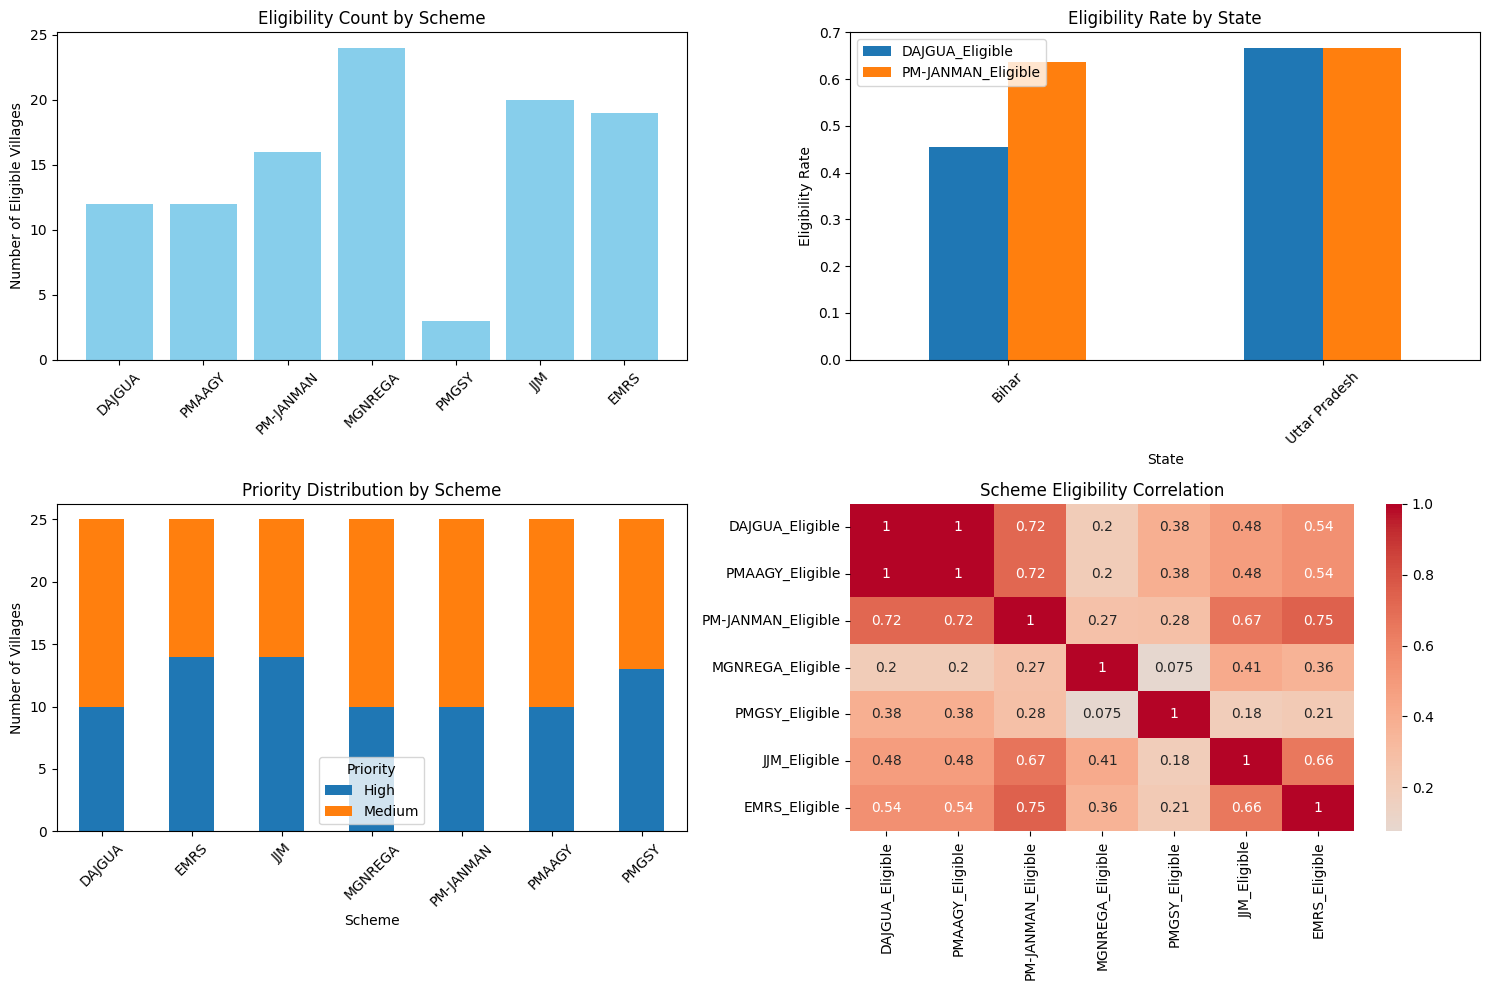

In [ ]:
# Create visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Eligibility Count by Scheme
plt.subplot(2, 2, 1)
eligibility_counts = [dss_results[f'{scheme}_Eligible'].sum() for scheme in schemes]
plt.bar(schemes, eligibility_counts, color='skyblue')
plt.title('Eligibility Count by Scheme')
plt.xticks(rotation=45)
plt.ylabel('Number of Eligible Villages')

# Plot 2: Eligibility by State
plt.subplot(2, 2, 2)
state_eligibility = dss_results.groupby('State')[['DAJGUA_Eligible', 'PM-JANMAN_Eligible']].mean()
state_eligibility.plot(kind='bar', ax=plt.gca())
plt.title('Eligibility Rate by State')
plt.xticks(rotation=45)
plt.ylabel('Eligibility Rate')

# Plot 3: Priority Distribution
plt.subplot(2, 2, 3)
priority_data = []
for scheme in schemes:
    priority_col = f'{scheme}_Priority'
    if priority_col in dss_results.columns:
        priority_counts = dss_results[priority_col].value_counts()
        for priority, count in priority_counts.items():
            priority_data.append({'Scheme': scheme, 'Priority': priority, 'Count': count})

priority_df = pd.DataFrame(priority_data)
if not priority_df.empty:
    pivot_df = priority_df.pivot(index='Scheme', columns='Priority', values='Count').fillna(0)
    pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title('Priority Distribution by Scheme')
    plt.xticks(rotation=45)
    plt.ylabel('Number of Villages')

# Plot 4: Correlation Heatmap
plt.subplot(2, 2, 4)
eligibility_cols = [f'{scheme}_Eligible' for scheme in schemes if f'{scheme}_Eligible' in dss_results.columns]
correlation_matrix = dss_results[eligibility_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=plt.gca())
plt.title('Scheme Eligibility Correlation')

plt.tight_layout()
plt.show()

In [ ]:
def generate_detailed_report(dss_results, original_data):
    """Generate detailed eligibility report"""
    report_data = []

    for idx, row in dss_results.iterrows():
        village_name = row['Village_Name']
        original_row = original_data[original_data['Village_Name'] == village_name].iloc[0]

        eligible_schemes = []
        for scheme in schemes:
            if row[f'{scheme}_Eligible'] == 1:
                eligible_schemes.append(scheme)

        report_entry = {
            'Village_Name': village_name,
            'District': row['District'],
            'State': row['State'],
            'ST_PVTG_Household': 'Yes' if original_row['ST_PVTG_Household'] == 1 else 'No',
            'BPL': 'Yes' if original_row['BPL'] == 1 else 'No',
            'Literacy_Rate': original_row['Literacy_Rate_pct'],
            'Eligible_Schemes': ', '.join(eligible_schemes) if eligible_schemes else 'None',
            'Number_of_Eligible_Schemes': len(eligible_schemes),
            'Priority_Schemes': ', '.join([scheme for scheme in eligible_schemes
                                         if row[f'{scheme}_Priority'] == 'High'])
        }

        report_data.append(report_entry)

    return pd.DataFrame(report_data)

# Generate detailed report
detailed_report = generate_detailed_report(dss_results, dummy_data)
print("Detailed Eligibility Report:")
print(detailed_report.head(10))

# Save results
dss_results.to_csv('dss_evaluation_results.csv', index=False)
detailed_report.to_csv('detailed_eligibility_report.csv', index=False)

print("\nResults saved to CSV files!")

Detailed Eligibility Report:
  Village_Name     District          State ST_PVTG_Household BPL  \
0       Rampur     Varanasi  Uttar Pradesh                No  No   
1     Nandgaon     Mirzapur  Uttar Pradesh                No  No   
2       Rajpur      Jaunpur  Uttar Pradesh                No  No   
3   Bhawanipur        Patna          Bihar                No  No   
4     Gopalpur      Nalanda          Bihar                No  No   
5    Dharampur  Muzaffarpur          Bihar                No  No   
6    Sultanpur   Samastipur          Bihar                No  No   
7        Pipra        Saran          Bihar                No  No   
8    Basantpur        Siwan          Bihar                No  No   
9      Amarpur    Gopalganj          Bihar                No  No   

   Literacy_Rate                               Eligible_Schemes  \
0           31.4  DAJGUA, PMAAGY, PM-JANMAN, MGNREGA, JJM, EMRS   
1           52.5                                        MGNREGA   
2           44.8  DAJ

In [ ]:
def get_recommendations_for_village(village_name, dss_results, detailed_report):
    """Get specific recommendations for a village"""
    village_data = detailed_report[detailed_report['Village_Name'] == village_name]

    if village_data.empty:
        return f"No data found for village: {village_name}"

    village_info = village_data.iloc[0]

    print(f"=== Recommendations for {village_name}, {village_info['District']} ===")
    print(f"State: {village_info['State']}")
    print(f"ST/PVTG Household: {village_info['ST_PVTG_Household']}")
    print(f"BPL Status: {village_info['BPL']}")
    print(f"Literacy Rate: {village_info['Literacy_Rate']}%")
    print(f"\nEligible Schemes: {village_info['Eligible_Schemes']}")
    print(f"Total Eligible Schemes: {village_info['Number_of_Eligible_Schemes']}")

    if village_info['Priority_Schemes']:
        print(f"\n🚀 HIGH PRIORITY SCHEMES: {village_info['Priority_Schemes']}")

    # Additional recommendations based on characteristics
    recommendations = []

    if village_info['ST_PVTG_Household'] == 'Yes':
        recommendations.append("Focus on tribal welfare schemes (DAJGUA, PM-JANMAN)")

    if village_info['BPL'] == 'Yes':
        recommendations.append("Prioritize poverty alleviation programs")

    if float(village_info['Literacy_Rate']) < 60:
        recommendations.append("Educational development schemes needed")

    if recommendations:
        print("\n📋 Additional Recommendations:")
        for rec in recommendations:
            print(f"• {rec}")

    return village_info

# Test with a specific village
sample_village = "Rampur"
get_recommendations_for_village(sample_village, dss_results, detailed_report)

=== Recommendations for Rampur, Varanasi ===
State: Uttar Pradesh
ST/PVTG Household: No
BPL Status: No
Literacy Rate: 31.4%

Eligible Schemes: DAJGUA, PMAAGY, PM-JANMAN, MGNREGA, JJM, EMRS
Total Eligible Schemes: 6

🚀 HIGH PRIORITY SCHEMES: DAJGUA, PMAAGY, PM-JANMAN, MGNREGA

📋 Additional Recommendations:
• Educational development schemes needed


,0
Village_Name,Rampur
District,Varanasi
State,Uttar Pradesh
ST_PVTG_Household,No
BPL,No
Literacy_Rate,31.4
Eligible_Schemes,"DAJGUA, PMAAGY, PM-JANMAN, MGNREGA, JJM, EMRS"
Number_of_Eligible_Schemes,6
Priority_Schemes,"DAJGUA, PMAAGY, PM-JANMAN, MGNREGA"


In [ ]:
def get_recommendations_for_village(village_name, dss_results, detailed_report):
    """Get specific recommendations for a village"""
    village_data = detailed_report[detailed_report['Village_Name'] == village_name]

    if village_data.empty:
        return f"No data found for village: {village_name}"

    village_info = village_data.iloc[0]

    print(f"=== Recommendations for {village_name}, {village_info['District']} ===")
    print(f"State: {village_info['State']}")
    print(f"ST/PVTG Household: {village_info['ST_PVTG_Household']}")
    print(f"BPL Status: {village_info['BPL']}")
    print(f"Literacy Rate: {village_info['Literacy_Rate']}%")
    print(f"\nEligible Schemes: {village_info['Eligible_Schemes']}")
    print(f"Total Eligible Schemes: {village_info['Number_of_Eligible_Schemes']}")

    if village_info['Priority_Schemes']:
        print(f"\n🚀 HIGH PRIORITY SCHEMES: {village_info['Priority_Schemes']}")

    # Additional recommendations based on characteristics
    recommendations = []

    if village_info['ST_PVTG_Household'] == 'Yes':
        recommendations.append("Focus on tribal welfare schemes (DAJGUA, PM-JANMAN)")

    if village_info['BPL'] == 'Yes':
        recommendations.append("Prioritize poverty alleviation programs")

    if float(village_info['Literacy_Rate']) < 60:
        recommendations.append("Educational development schemes needed")

    if recommendations:
        print("\n📋 Additional Recommendations:")
        for rec in recommendations:
            print(f"• {rec}")

    return village_info

# Test with a specific village
sample_village = "Rampur"
get_recommendations_for_village(sample_village, dss_results, detailed_report)

=== Recommendations for Rampur, Varanasi ===
State: Uttar Pradesh
ST/PVTG Household: No
BPL Status: No
Literacy Rate: 31.4%

Eligible Schemes: DAJGUA, PMAAGY, PM-JANMAN, MGNREGA, JJM, EMRS
Total Eligible Schemes: 6

🚀 HIGH PRIORITY SCHEMES: DAJGUA, PMAAGY, PM-JANMAN, MGNREGA

📋 Additional Recommendations:
• Educational development schemes needed


,0
Village_Name,Rampur
District,Varanasi
State,Uttar Pradesh
ST_PVTG_Household,No
BPL,No
Literacy_Rate,31.4
Eligible_Schemes,"DAJGUA, PMAAGY, PM-JANMAN, MGNREGA, JJM, EMRS"
Number_of_Eligible_Schemes,6
Priority_Schemes,"DAJGUA, PMAAGY, PM-JANMAN, MGNREGA"


In [ ]:
# Generate summary statistics
print("=== DSS SYSTEM SUMMARY ===")
print(f"Total Villages Processed: {len(dss_results)}")
print(f"States Covered: {dss_results['State'].nunique()}")

print("\n📊 Scheme-wise Eligibility:")
summary_stats = []
for scheme in schemes:
    eligible = dss_results[f'{scheme}_Eligible'].sum()
    percentage = (eligible / len(dss_results)) * 100
    summary_stats.append({
        'Scheme': scheme,
        'Eligible_Villages': eligible,
        'Eligibility_Rate': f"{percentage:.1f}%"
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df)

print("\n🏆 Top 5 Villages with Most Eligible Schemes:")
villages_by_schemes = detailed_report.nlargest(5, 'Number_of_Eligible_Schemes')[['Village_Name', 'District', 'Number_of_Eligible_Schemes', 'Eligible_Schemes']]
print(villages_by_schemes)

=== DSS SYSTEM SUMMARY ===
Total Villages Processed: 25
States Covered: 2

📊 Scheme-wise Eligibility:
      Scheme  Eligible_Villages Eligibility_Rate
0     DAJGUA                 12            48.0%
1     PMAAGY                 12            48.0%
2  PM-JANMAN                 16            64.0%
3    MGNREGA                 24            96.0%
4      PMGSY                  3            12.0%
5        JJM                 20            80.0%
6       EMRS                 19            76.0%

🏆 Top 5 Villages with Most Eligible Schemes:
   Village_Name   District  Number_of_Eligible_Schemes  \
11     Chandpur  Madhubani                           7   
18     Lakhnaur  Madhepura                           7   
24       Rosera      Buxar                           7   
0        Rampur   Varanasi                           6   
2        Rajpur    Jaunpur                           6   

                                     Eligible_Schemes  
11  DAJGUA, PMAAGY, PM-JANMAN, MGNREGA, PMGSY, JJM...  